In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('employee_records_cleaned.csv')

In [3]:
df

,Employee_ID,Employee_Name,Age,Country,Department,Position,Salary,Joining_Date,Joining_Year,Joining_Month,Joining_Month_Name,Tenure_Years,Age_Group
0,1,Daniel Taylor,25,UK,HR,Analyst,142278.32,2023-06-04,2023,6,June,1.8,18-25
1,2,Ethan Brown,44,India,Marketing,Executive,98549.20,2018-01-13,2018,1,January,7.1,36-45
2,3,Sophia Martinez,51,Japan,Finance,Developer,85565.84,2015-04-30,2015,4,April,9.9,46-55
3,4,Ethan Martinez,47,Germany,Support,Analyst,34513.67,2015-06-17,2015,6,June,9.7,46-55
4,5,Mia Brown,32,Australia,Support,Consultant,45339.72,2019-02-22,2019,2,February,6.0,26-35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,Mia Brown,42,Australia,Support,Manager,133474.82,2015-07-03,2015,7,July,9.7,36-45
29996,29997,Mason Thomas,41,Mexico,Engineering,Assistant,140793.59,2023-10-12,2023,10,October,1.4,36-45
29997,29998,Lily Anderson,44,India,Marketing,Developer,68464.72,2021-06-28,2021,6,June,3.7,36-45
29998,29999,Mason Taylor,46,Brazil,Finance,Assistant,148323.28,2017-11-11,2017,11,November,7.3,46-55


In [4]:
print(df.shape)
df.head()

(30000, 13)


,Employee_ID,Employee_Name,Age,Country,Department,Position,Salary,Joining_Date,Joining_Year,Joining_Month,Joining_Month_Name,Tenure_Years,Age_Group
0,1,Daniel Taylor,25,UK,HR,Analyst,142278.32,2023-06-04,2023,6,June,1.8,18-25
1,2,Ethan Brown,44,India,Marketing,Executive,98549.20,2018-01-13,2018,1,January,7.1,36-45
2,3,Sophia Martinez,51,Japan,Finance,Developer,85565.84,2015-04-30,2015,4,April,9.9,46-55
3,4,Ethan Martinez,47,Germany,Support,Analyst,34513.67,2015-06-17,2015,6,June,9.7,46-55
4,5,Mia Brown,32,Australia,Support,Consultant,45339.72,2019-02-22,2019,2,February,6.0,26-35


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         30000 non-null  int64  
 1   Employee_Name       30000 non-null  object 
 2   Age                 30000 non-null  int64  
 3   Country             30000 non-null  object 
 4   Department          30000 non-null  object 
 5   Position            30000 non-null  object 
 6   Salary              30000 non-null  float64
 7   Joining_Date        30000 non-null  object 
 8   Joining_Year        30000 non-null  int64  
 9   Joining_Month       30000 non-null  int64  
 10  Joining_Month_Name  30000 non-null  object 
 11  Tenure_Years        30000 non-null  float64
 12  Age_Group           30000 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 3.0+ MB


### EDA Part 1 — Workforce Overview

#### Understand how the workforce is distributed across departments, positions, and countries.

In [6]:
df['Employee_ID'].nunique()

30000

In [7]:
df['Department'].value_counts()

Department
Engineering    5070
Sales          5019
Marketing      5007
Support        4990
HR             4976
Finance        4938
Name: count, dtype: int64

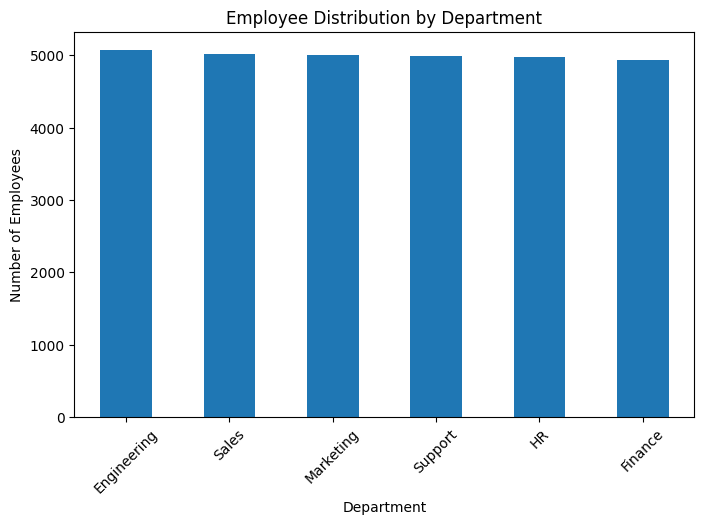

In [12]:
department_counts = df['Department'].value_counts()

plt.figure(figsize=(8, 5))
department_counts.plot(kind='bar')

plt.title('Employee Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.show()

In [13]:
df['Position'].value_counts()

Position
Executive     5124
Consultant    5022
Analyst       5008
Developer     4988
Assistant     4934
Manager       4924
Name: count, dtype: int64

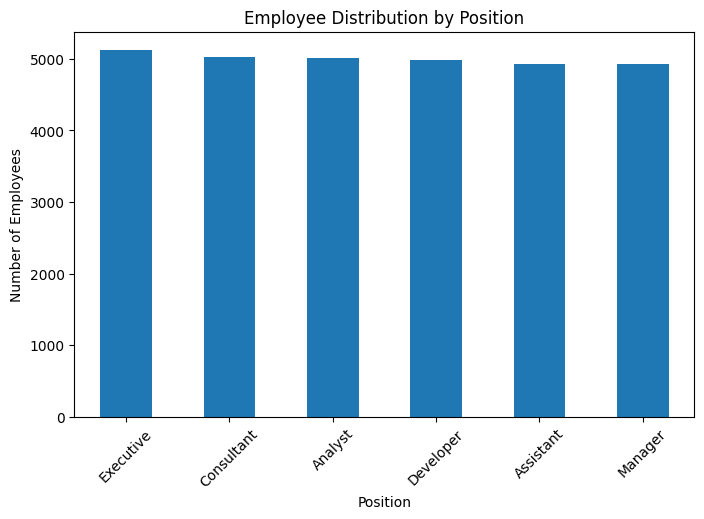

In [15]:
position_counts = df['Position'].value_counts()

plt.figure(figsize=(8, 5))
position_counts.plot(kind='bar')

plt.title('Employee Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.show()

In [16]:
df['Country'].value_counts()

Country
Germany      3090
Australia    3052
UK           3021
France       3010
Mexico       2991
India        2985
Canada       2969
USA          2967
Brazil       2961
Japan        2954
Name: count, dtype: int64

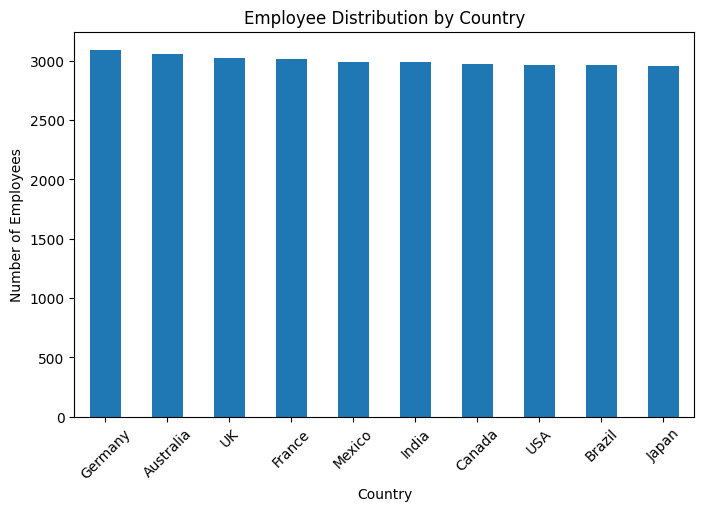

In [17]:
country_counts = df['Country'].value_counts()

plt.figure(figsize=(8, 5))
country_counts.plot(kind='bar')

plt.title('Employee Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.show()

In [18]:
df[['Age', 'Salary', 'Tenure_Years']].describe()

,Age,Salary,Tenure_Years
count,30000.000000,30000.000000,30000.000000
mean,40.978067,89826.142610,5.008690
std,11.234432,34625.270533,2.879624
min,22.000000,30004.780000,0.000000
25%,31.000000,59546.715000,2.500000
50%,41.000000,89544.810000,5.000000
75%,51.000000,119836.545000,7.500000
max,60.000000,149996.390000,10.000000


### EDA Part 2 — Employee Demographics
#### What does the employee population look like in terms of age and workforce age groups?

In [21]:
df['Age'].describe()

count    30000.000000
mean        40.978067
std         11.234432
min         22.000000
25%         31.000000
50%         41.000000
75%         51.000000
max         60.000000
Name: Age, dtype: float64

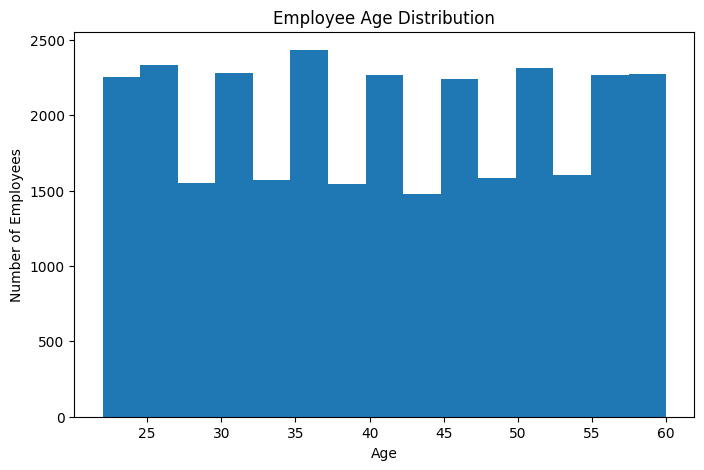

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df['Age'], bins=15)

plt.title('Employee Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Employees')

plt.show()

In [25]:
age_group_counts = df['Age_Group'].value_counts().sort_index()

age_group_counts

Age_Group
18-25    3046
26-35    7766
36-45    7655
46-55    7781
56+      3752
Name: count, dtype: int64

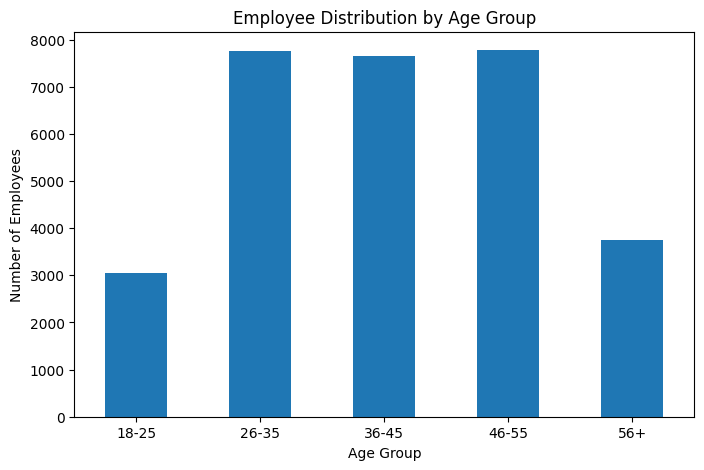

In [26]:
plt.figure(figsize=(8, 5))

age_group_counts.plot(kind='bar')

plt.title('Employee Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

plt.show()

In [28]:
department_age = (
    df.groupby('Department')['Age']
    .mean()
    .sort_values(ascending=False)
)

department_age

Department
Finance        41.162009
Engineering    41.048915
Marketing      41.028360
Sales          40.929468
Support        40.880561
HR             40.819534
Name: Age, dtype: float64

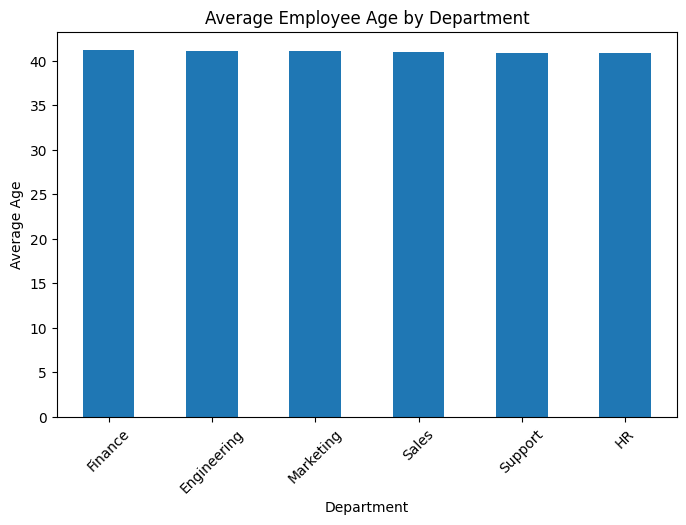

In [29]:
plt.figure(figsize=(8, 5))

department_age.plot(kind='bar')

plt.title('Average Employee Age by Department')
plt.xlabel('Department')
plt.ylabel('Average Age')
plt.xticks(rotation=45)

plt.show()

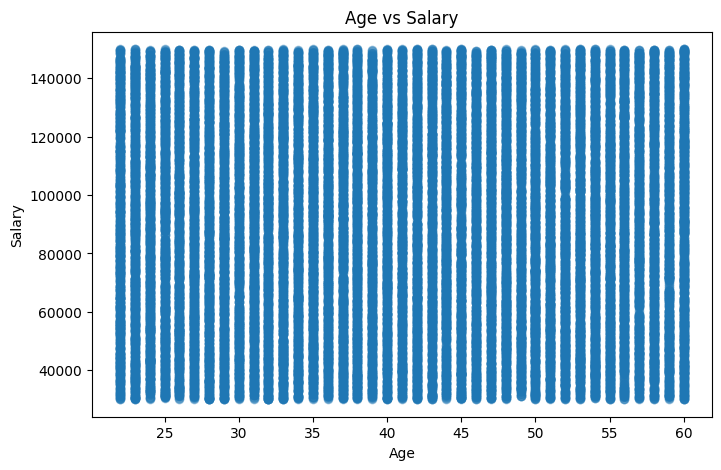

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Age'], df['Salary'], alpha=0.4)

plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')

plt.show()

### EDA Part 3 — Salary Analysis
#### How are salaries distributed, and how do salaries vary across departments, positions, and employee characteristics?

In [31]:
df['Salary'].describe()

count     30000.000000
mean      89826.142610
std       34625.270533
min       30004.780000
25%       59546.715000
50%       89544.810000
75%      119836.545000
max      149996.390000
Name: Salary, dtype: float64

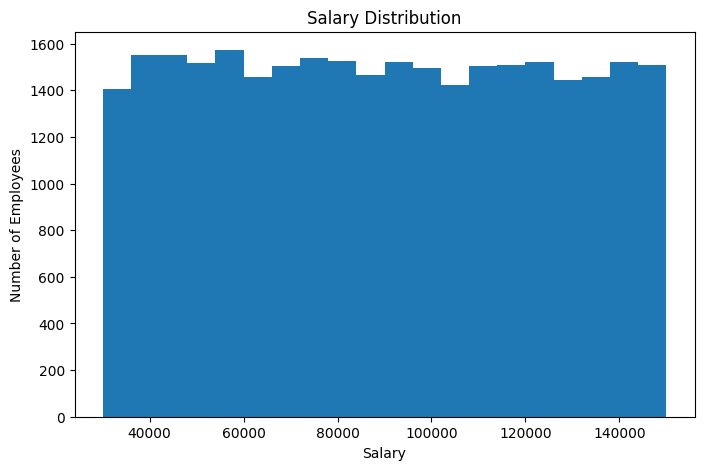

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(df['Salary'], bins=20)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')

plt.show()

In [34]:
department_salary = (
    df.groupby('Department')['Salary']
    .agg(['mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

department_salary

,mean,median,min,max
Department,,,,
Support,90649.139924,91096.825,30048.30,149971.79
Engineering,90159.593972,90502.160,30004.78,149989.60
HR,89930.383159,89622.390,30021.75,149995.00
Marketing,89834.054781,89256.080,30024.84,149953.43
Finance,89526.906612,88854.415,30019.60,149841.52
Sales,88854.226918,87830.750,30017.91,149996.39


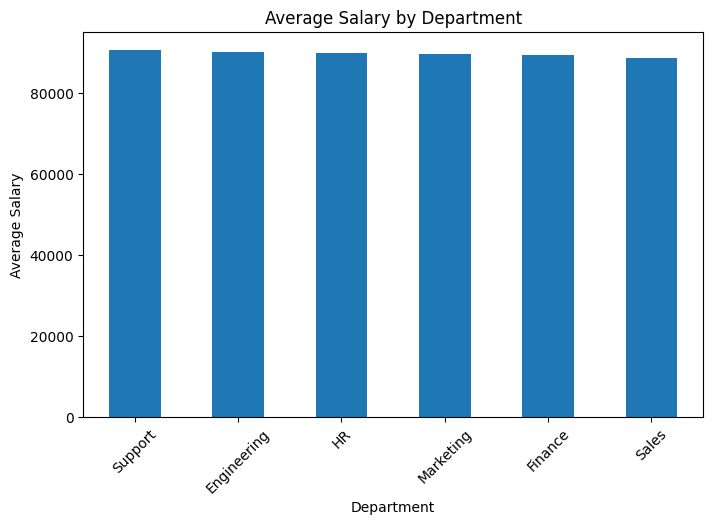

In [35]:
plt.figure(figsize=(8, 5))

department_salary['mean'].plot(kind='bar')

plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)

plt.show()

In [36]:
position_salary = (
    df.groupby('Position')['Salary']
    .agg(['mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

position_salary

,mean,median,min,max
Position,,,,
Executive,90604.776887,90608.580,30053.71,149979.37
Assistant,90436.258433,91050.815,30019.60,149964.65
Analyst,89909.850405,89196.615,30021.75,149989.60
Developer,89528.068087,89271.065,30004.78,149996.39
Manager,89444.872380,88848.530,30037.83,149994.40
Consultant,89018.681077,87522.870,30017.91,149989.17


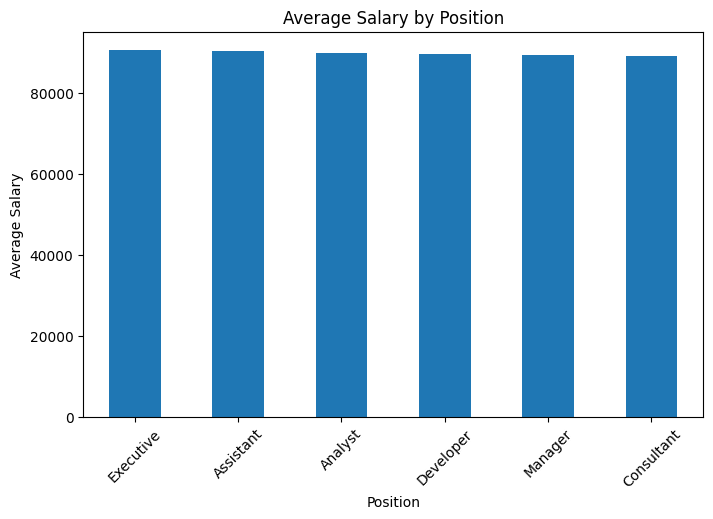

In [37]:
plt.figure(figsize=(8, 5))

position_salary['mean'].plot(kind='bar')

plt.title('Average Salary by Position')
plt.xlabel('Position')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)

plt.show()

In [38]:
country_salary = (
    df.groupby('Country')['Salary']
    .agg(['mean', 'median'])
    .sort_values('mean', ascending=False)
)

country_salary

,mean,median
Country,,
Japan,90774.064838,92857.345
Mexico,90416.405289,91183.250
USA,90283.869127,90452.930
Germany,90254.797916,90403.595
Australia,90156.989371,89905.530
India,89895.772975,89053.580
Canada,89253.021192,88272.270
UK,89171.826670,88933.690
Brazil,89112.841169,87898.560


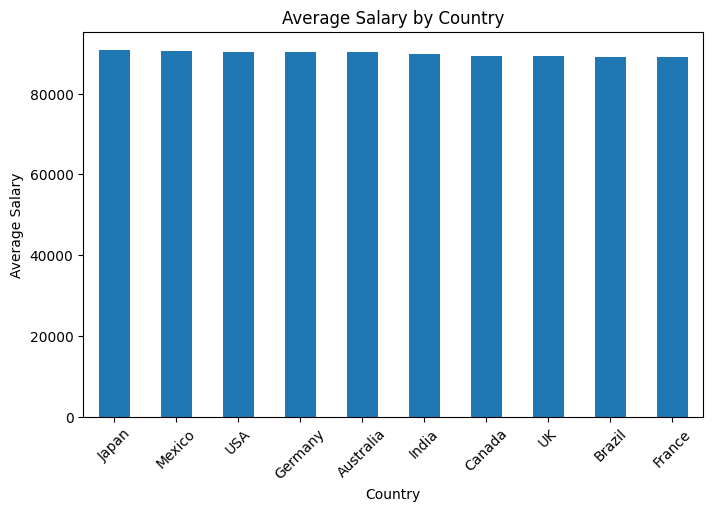

In [39]:
plt.figure(figsize=(8, 5))

country_salary['mean'].plot(kind='bar')

plt.title('Average Salary by Country')
plt.xlabel('Country')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)

plt.show()

In [43]:
tenure_salary = (
    df.groupby('Tenure_Years')['Salary']
    .mean()
    .reset_index()
)

tenure_salary.head()

,Tenure_Years,Salary
0,0.0,92030.147421
1,0.1,87126.342813
2,0.2,91132.373207
3,0.3,89234.499389
4,0.4,96410.297500


In [44]:
tenure_salary = (
    df.groupby('Tenure_Years')['Salary']
    .mean()
    .reset_index()
)

tenure_salary.head()

,Tenure_Years,Salary
0,0.0,92030.147421
1,0.1,87126.342813
2,0.2,91132.373207
3,0.3,89234.499389
4,0.4,96410.297500


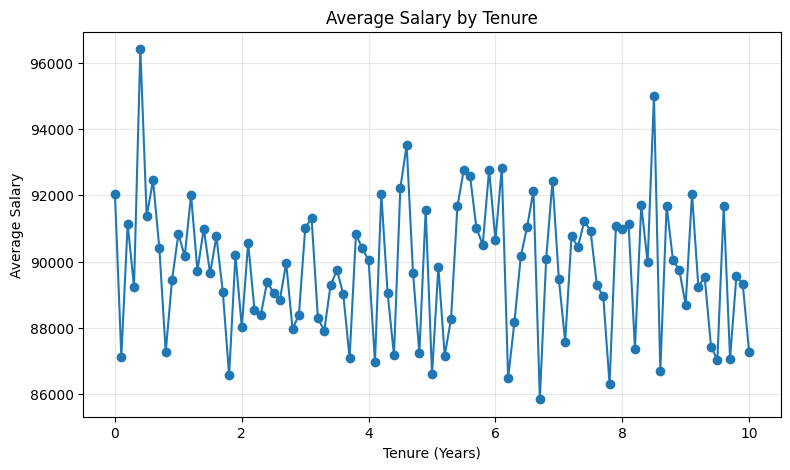

In [45]:
plt.figure(figsize=(9, 5))

plt.plot(
    tenure_salary['Tenure_Years'],
    tenure_salary['Salary'],
    marker='o'
)

plt.title('Average Salary by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Average Salary')

plt.grid(alpha=0.3)
plt.show()

In [46]:
correlation = df['Tenure_Years'].corr(df['Salary'])

print(f'Tenure-Salary Correlation: {correlation:.3f}')

Tenure-Salary Correlation: -0.003


### EDA Part 4 — Department & Position Analysis

In [47]:
# 1. Employee count by department

department_count = (
    df['Department']
    .value_counts()
    .rename('Employee_Count')
)

department_count

Department
Engineering    5070
Sales          5019
Marketing      5007
Support        4990
HR             4976
Finance        4938
Name: Employee_Count, dtype: int64

In [48]:
# 2. Department salary + employee count

department_summary = (
    df.groupby('Department')
    .agg(
        Employee_Count=('Employee_ID', 'nunique'),
        Average_Salary=('Salary', 'mean'),
        Median_Salary=('Salary', 'median'),
        Average_Age=('Age', 'mean'),
        Average_Tenure=('Tenure_Years', 'mean')
    )
    .sort_values('Employee_Count', ascending=False)
)

department_summary

,Employee_Count,Average_Salary,Median_Salary,Average_Age,Average_Tenure
Department,,,,,
Engineering,5070,90159.593972,90502.160,41.048915,5.010552
Sales,5019,88854.226918,87830.750,40.929468,4.984997
Marketing,5007,89834.054781,89256.080,41.028360,5.089734
Support,4990,90649.139924,91096.825,40.880561,4.989699
HR,4976,89930.383159,89622.390,40.819534,4.980145
Finance,4938,89526.906612,88854.415,41.162009,4.996638


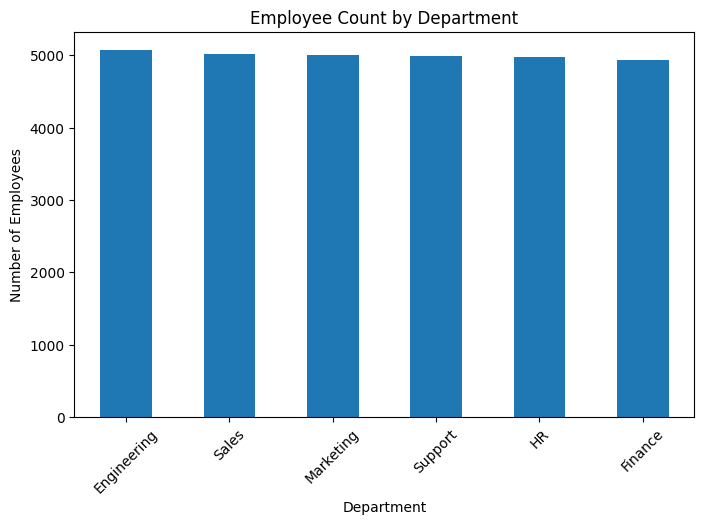

In [49]:
# 3. Department workforce visualization

plt.figure(figsize=(8, 5))

department_summary['Employee_Count'].plot(kind='bar')

plt.title('Employee Count by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.show()

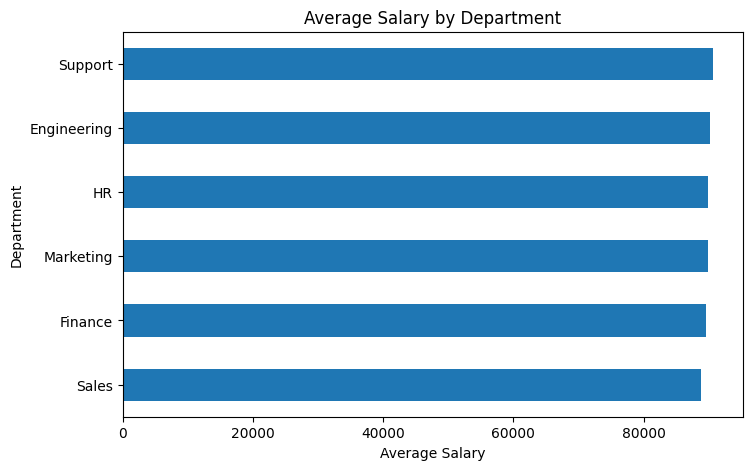

In [50]:
# 4. Department average salary

plt.figure(figsize=(8, 5))

department_summary['Average_Salary'].sort_values().plot(kind='barh')

plt.title('Average Salary by Department')
plt.xlabel('Average Salary')
plt.ylabel('Department')

plt.show()

In [52]:
# 5. Position-wise workforce

position_summary = (
    df.groupby('Position')
    .agg(
        Employee_Count=('Employee_ID', 'nunique'),
        Average_Salary=('Salary', 'mean'),
        Median_Salary=('Salary', 'median')
    )
    .sort_values('Average_Salary', ascending=False)
)

position_summary

,Employee_Count,Average_Salary,Median_Salary
Position,,,
Executive,5124,90604.776887,90608.580
Assistant,4934,90436.258433,91050.815
Analyst,5008,89909.850405,89196.615
Developer,4988,89528.068087,89271.065
Manager,4924,89444.872380,88848.530
Consultant,5022,89018.681077,87522.870


In [53]:
# 6. Department × Position

department_position = pd.crosstab(
    df['Department'],
    df['Position']
)

department_position

Position,Analyst,Assistant,Consultant,Developer,Executive,Manager
Department,,,,,,
Engineering,867,825,849,805,877,847
Finance,835,786,867,850,825,775
HR,814,860,849,818,853,782
Marketing,818,824,790,865,866,844
Sales,844,829,828,829,863,826
Support,830,810,839,821,840,850


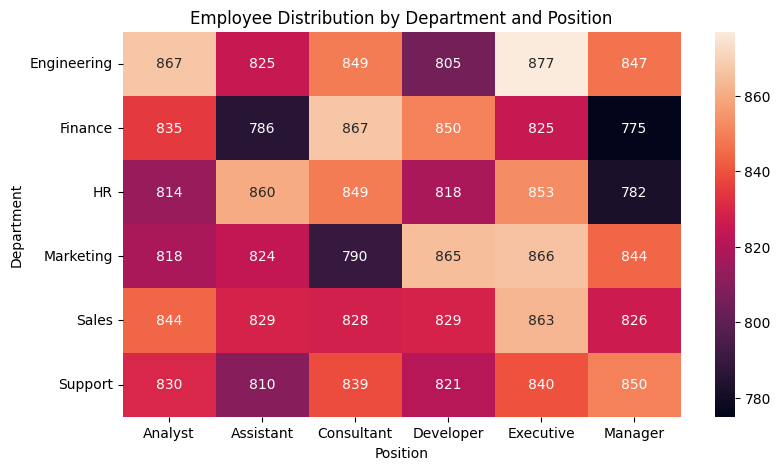

In [54]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    department_position,
    annot=True,
    fmt='d'
)

plt.title('Employee Distribution by Department and Position')
plt.xlabel('Position')
plt.ylabel('Department')

plt.show()

### EDA Part 5 — Country & Hiring Trend Analysis

In [55]:
# 1. Employee distribution by country

country_summary = (
    df.groupby('Country')
    .agg(
        Employee_Count=('Employee_ID', 'nunique'),
        Average_Salary=('Salary', 'mean'),
        Average_Age=('Age', 'mean'),
        Average_Tenure=('Tenure_Years', 'mean')
    )
    .sort_values('Employee_Count', ascending=False)
)

country_summary

,Employee_Count,Average_Salary,Average_Age,Average_Tenure
Country,,,,
Germany,3090,90254.797916,41.630421,5.066958
Australia,3052,90156.989371,40.938729,4.907208
UK,3021,89171.826670,40.673949,5.038894
France,3010,88937.279870,41.369103,5.007475
Mexico,2991,90416.405289,40.750251,5.004547
India,2985,89895.772975,40.991960,5.009079
Canada,2969,89253.021192,40.414955,5.012260
USA,2967,90283.869127,40.794068,4.982575
Brazil,2961,89112.841169,41.161432,4.989092


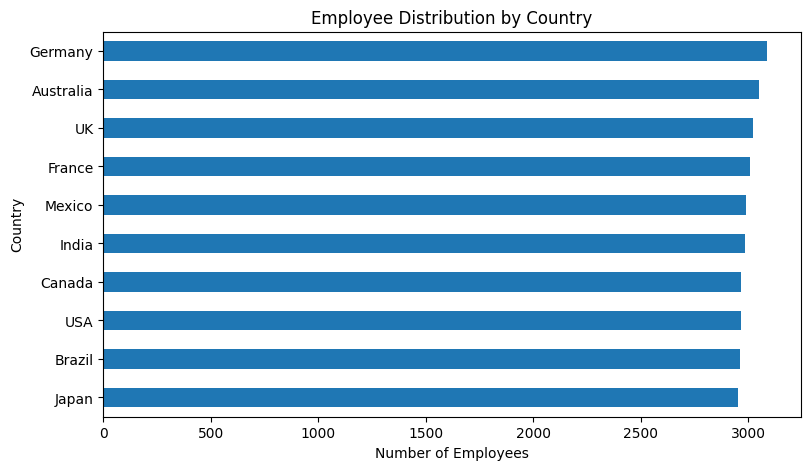

In [56]:
# 2. Country-wise employee count

plt.figure(figsize=(9, 5))

country_summary['Employee_Count'].sort_values().plot(kind='barh')

plt.title('Employee Distribution by Country')
plt.xlabel('Number of Employees')
plt.ylabel('Country')

plt.show()

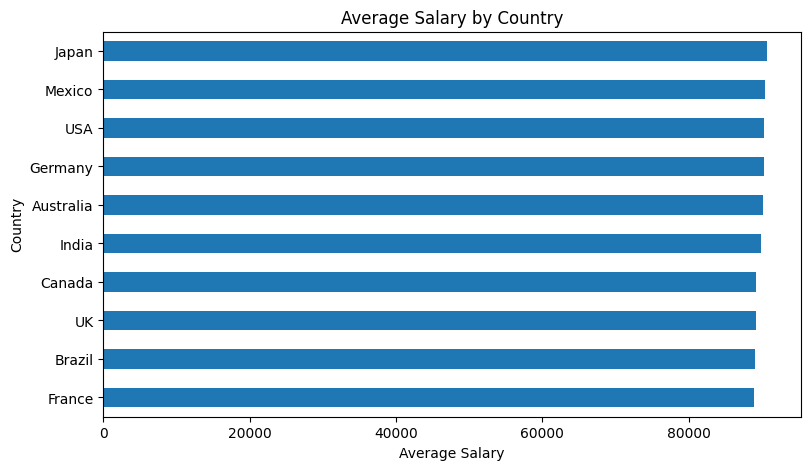

In [57]:
# 3. Average salary by country

plt.figure(figsize=(9, 5))

country_summary['Average_Salary'].sort_values().plot(kind='barh')

plt.title('Average Salary by Country')
plt.xlabel('Average Salary')
plt.ylabel('Country')

plt.show()

In [58]:
# 4. Employees joined by year

# This is one of the most useful HR analyses.

joining_year = (
    df.groupby('Joining_Year')['Employee_ID']
    .nunique()
)

joining_year

Joining_Year
2015    2507
2016    2878
2017    3000
2018    3079
2019    3084
2020    2956
2021    3016
2022    2966
2023    3022
2024    2944
2025     548
Name: Employee_ID, dtype: int64

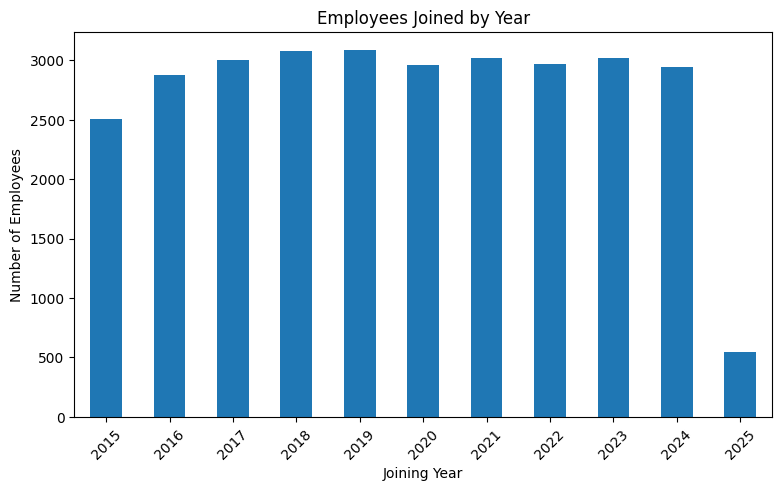

In [59]:
plt.figure(figsize=(9, 5))

joining_year.plot(kind='bar')

plt.title('Employees Joined by Year')
plt.xlabel('Joining Year')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)

plt.show()

In [60]:
# 5. Hiring trend over time


monthly_hiring = (
    df.groupby('Joining_Month')['Employee_ID']
    .nunique()
)

monthly_hiring

Joining_Month
1     2569
2     2309
3     2600
4     2436
5     2527
6     2421
7     2522
8     2653
9     2388
10    2598
11    2401
12    2576
Name: Employee_ID, dtype: int64

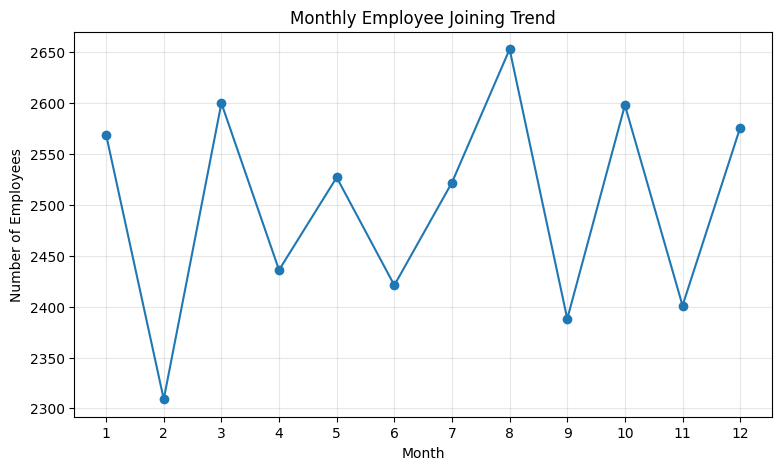

In [61]:
plt.figure(figsize=(9, 5))

monthly_hiring.plot(kind='line', marker='o')

plt.title('Monthly Employee Joining Trend')
plt.xlabel('Month')
plt.ylabel('Number of Employees')

plt.xticks(range(1, 13))

plt.grid(alpha=0.3)
plt.show()

In [62]:
# 6. Hiring trend by department


year_department = pd.crosstab(
    df['Joining_Year'],
    df['Department']
)

year_department

Department,Engineering,Finance,HR,Marketing,Sales,Support
Joining_Year,,,,,,
2015,429,419,391,453,409,406
2016,502,441,464,510,482,479
2017,507,512,491,519,481,490
2018,493,539,524,494,504,525
2019,535,469,527,510,551,492
2020,493,467,510,481,498,507
2021,492,513,511,471,495,534
2022,509,500,502,496,495,464
2023,533,499,473,485,531,501


<Figure size 1000x600 with 0 Axes>

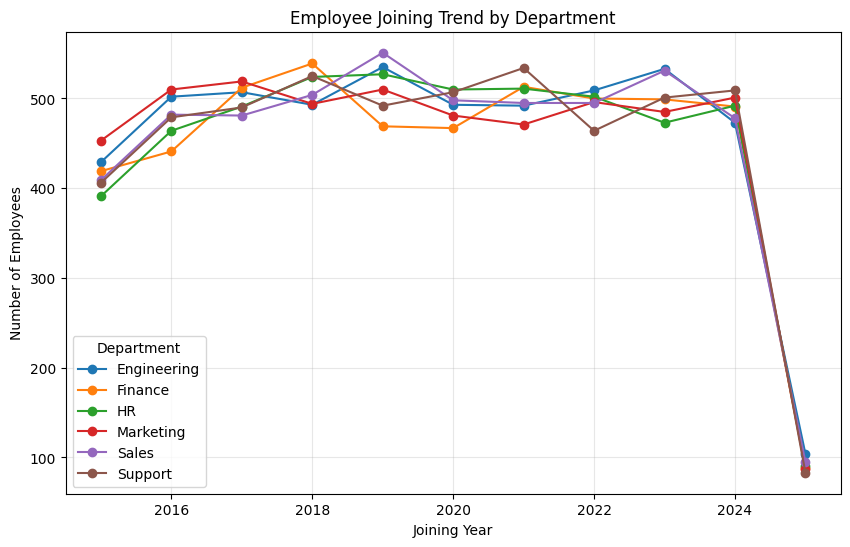

In [64]:
plt.figure(figsize=(10, 6))

year_department.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Employee Joining Trend by Department')
plt.xlabel('Joining Year')
plt.ylabel('Number of Employees')

plt.grid(alpha=0.3)
plt.legend(title='Department')

plt.show()

### EDA Part 6 — Tenure Analysis
#### How long have employees been with the organization, and how does tenure vary across departments and positions?

In [65]:
df['Tenure_Years'].describe()

count    30000.000000
mean         5.008690
std          2.879624
min          0.000000
25%          2.500000
50%          5.000000
75%          7.500000
max         10.000000
Name: Tenure_Years, dtype: float64

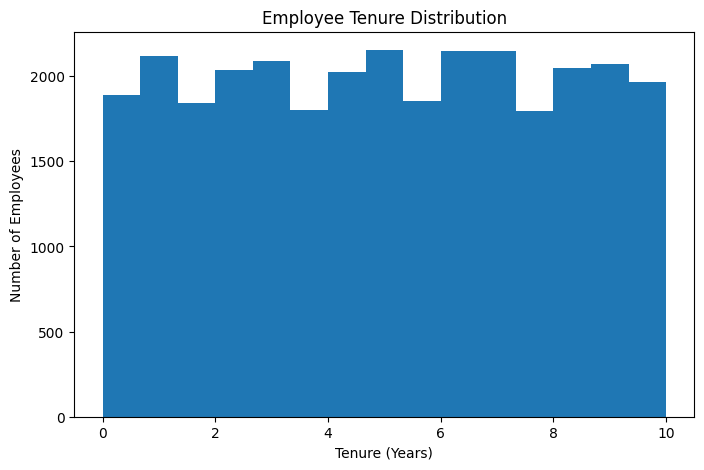

In [66]:
plt.figure(figsize=(8, 5))

plt.hist(df['Tenure_Years'], bins=15)

plt.title('Employee Tenure Distribution')
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Employees')

plt.show()

In [67]:
# Average tenure by department
department_tenure = (
    df.groupby('Department')['Tenure_Years']
    .mean()
    .sort_values(ascending=False)
)

department_tenure

Department
Marketing      5.089734
Engineering    5.010552
Finance        4.996638
Support        4.989699
Sales          4.984997
HR             4.980145
Name: Tenure_Years, dtype: float64

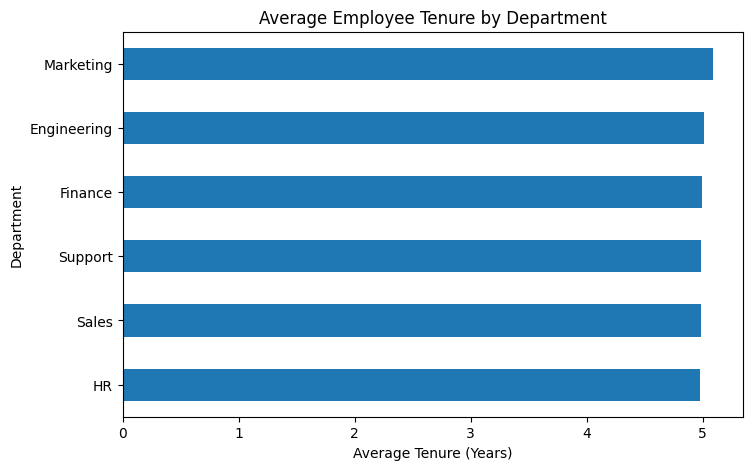

In [69]:
plt.figure(figsize=(8, 5))

department_tenure.sort_values().plot(kind='barh')

plt.title('Average Employee Tenure by Department')
plt.xlabel('Average Tenure (Years)')
plt.ylabel('Department')

plt.show()

In [71]:
# Tenure by position
position_tenure = (
    df.groupby('Position')['Tenure_Years']
    .mean()
    .sort_values(ascending=False)
)

position_tenure

Position
Executive     5.050664
Consultant    5.032816
Developer     5.021010
Manager       4.990333
Assistant     4.984151
Analyst       4.971506
Name: Tenure_Years, dtype: float64

In [73]:
tenure_bins = [0, 2, 5, 10, float('inf')]
tenure_labels = ['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']

df['Tenure_Group'] = pd.cut(
    df['Tenure_Years'],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)


In [74]:
tenure_group_counts = df['Tenure_Group'].value_counts().sort_index()

tenure_group_counts

Tenure_Group
0-2 Years      6146
3-5 Years      8908
6-10 Years    14946
10+ Years         0
Name: count, dtype: int64

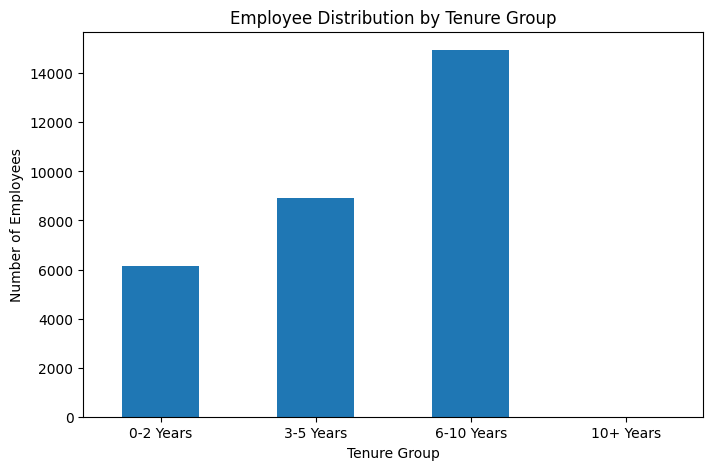

In [76]:
plt.figure(figsize=(8, 5))

tenure_group_counts.plot(kind='bar')

plt.title('Employee Distribution by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

plt.show()

In [78]:
# Tenure vs Department

tenure_summary = (
    df.groupby('Department')
    .agg(
        Employee_Count=('Employee_ID', 'nunique'),
        Average_Tenure=('Tenure_Years', 'mean'),
        Average_Salary=('Salary', 'mean')
    )
    .sort_values('Average_Tenure', ascending=False)
)

tenure_summary

,Employee_Count,Average_Tenure,Average_Salary
Department,,,
Marketing,5007,5.089734,89834.054781
Engineering,5070,5.010552,90159.593972
Finance,4938,4.996638,89526.906612
Support,4990,4.989699,90649.139924
Sales,5019,4.984997,88854.226918
HR,4976,4.980145,89930.383159


# Final EDA Summary

## Workforce Overview
- Analyzed employee distribution across departments, positions, and countries.
- Identified the overall workforce structure and major employee groups.

## Employee Demographics
- Examined employee age distribution and age-group composition.
- Compared average employee age across departments.
- Explored the relationship between age and salary.

## Salary Analysis
- Analyzed overall salary distribution.
- Compared average and median salaries across departments, positions, and countries.
- Examined the relationship between salary and employee tenure.

## Department & Position Analysis
- Compared workforce size across departments.
- Analyzed salary and employee characteristics at the department and position levels.
- Examined employee distribution across department-position combinations.

## Country & Hiring Trends
- Compared workforce distribution and average salary across countries.
- Analyzed employee joining patterns by year and month.
- Examined hiring trends across departments.

## Tenure Analysis
- Analyzed employee tenure distribution.
- Compared average tenure across departments and positions.
- Created tenure groups to understand workforce experience levels.

## Overall Observation
The EDA provides a structured view of workforce composition, salary patterns, departmental structure, geographic distribution, hiring trends, and employee tenure. These findings will be used to formulate business questions for SQL analysis and create an HR report in Excel.